#### Freshwater Height and Profile Potential Energy

This Jupyter notebook implements freshwater height (FWH) and profile potential energy (PPE) as defined in: **Gustafsson, Bo.** *High frequency variability of the surface layers
in the Skagerrak during SKAGEX* (1997). 

Both FWH (Eq. 1, in meters) and PPE (Eq. 2, m$^{3} s^{-2}$) are used as diagnostics for Norkyst-800, an operational ocean model developed and maintained by the Norwegian Meteorological Institute.


$
\begin{equation}
FWH = \frac{1}{S_{0}}\int_{0}^{-D} max[S_{0} - S(z), 0]\, dz
\tag{1}
\end{equation}
$

where $S_{0}$ represents the reference salinity (35), and *D* is the water depth. The PPE is given by:

$
\begin{equation}
PPE = \frac{g}{\rho_{0}}\int_{0}^{-D} max[\rho_{0} - \rho(z), 0]z\, dz
\tag{2}
\end{equation}
$

where *g* is the acceleration of gravity, and $\rho_{0}$ is the reference water density for T$_{0}$ = 8$^{\circ}$C and S$_{0}$.


\
\
\
\
\
\
\
\
Note: The integrations are based on two Fortran-90 codes, *integratefwh.f90* and *integrateppe.f90*. Both are available in this repository, but they must be compiled using *f2py* in order to be called. Run the following command in your terminal: **f2py -c --fcompiler=gfortran -m integratefwh integratefwh.f90**

Developers: Victor C. M. de Aguiar (victorm@met.no) and Kai H. Christensen (kaihc@met.no)

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from timeit import default_timer as timer
import cartopy.crs as ccrs # Geospatial data processing
import cartopy.feature as cfeature # Features (land, boundaries) from cartopy
from shapely.geometry.polygon import LinearRing
import cmocean
from netCDF4 import Dataset
import integratefwh
import integrateppe
import seawater as sw

# Function with the key functionalities

def fwh_ppe(model=None, day=None, month=None, year=None):

    # Organize date
    if day < 10:
        d = '0%i'%(day)
    else:
        d = '%i'%(day)
    
    if month < 10:
        m = '0%i'%(month)
    else:
        m = '%i'%(month)

    ID = str(year)+str(m)+d
    
    # Define which model domain we are using
    model = model
    
    if model != 0 or model != 70:
        print('Model must be 0 (whole domain) or 70 (Sulafjorden)')

    if model == 0:
        print('Whole domain requested')
        
        path = '/lustre/storeB/project/fou/hi/new_norkyst/his/'
        file = 'ocean_his.an.%s.nc'%(ID)

    if model == 70:
        print('Sulafjord domain requested')
        
        path = '/lustre/storeB/project/fou/hi/oper/norkyst_v3/forecast/his/%i/%s/%s/'%(year, m, d)
        file = 'norkyst160_his_sdepth_%sT00Z_m70_AN.nc'%(ID)

    df = xr.open_dataset(path+file, engine='netcdf4')

    # Define reference values here
    So = 35
    To = 8
    rho_o = sw.dens0(So, To)

    # Define variables and parameters from the requested model
    h = df.h[:,:]
    hc = df.hc
    Cs_w = df.Cs_w
    s_w = df.s_w
    Cs_r = df.Cs_r
    s_r = df.s_rho
    salt = df.salt
    temp = df.temp
    zeta = df.zeta

    # Get dimensions
    Nx = salt.shape[3]
    Ny = salt.shape[2]
    Nt = salt.shape[0]
    Nz = s_w.shape[0]

    # Calculate pressure and density for PPE
    S = (hc*s_r + h*Cs_r)/(hc + h)
    z = zeta + (zeta + h)*S
    z_masked_r = z.where(z > -50, drop=False)
    Z = np.swapaxes(z_masked_r, 3, -3)

    # Define array for FWH and PPE where values get stored 
    fwh = np.zeros_like(zeta)
    ppe = np.zeros_like(zeta)

    for n in range(Nt):
        fwh[n,:,:] = integratefwh.ifwh(salt[n,:], zeta[n,:], h, So, Cs_w, hc, s_w)

        # Estimate the density field
        p = sw.pres(np.swapaxes(Z[n,:], -1, 1), df.lat_rho.values)
        rho = sw.dens(salt[n,:], temp[n,:], p)
        
        ppe[n,:,:] = integrateppe.ippe(rho, zeta[n,:], h, rho_o, Cs_w, Cs_r, hc, s_w, s_r)

    return (df.lon_rho.values, df.lat_rho.values, fwh, ppe)

lon, lat, fwh, ppe = fwh_ppe(0, 4, 11, 2023)

Model must be 0 (whole domain) or 70 (Sulafjorden)
Whole domain requested


##### Let's plot the FWH using Cartopy

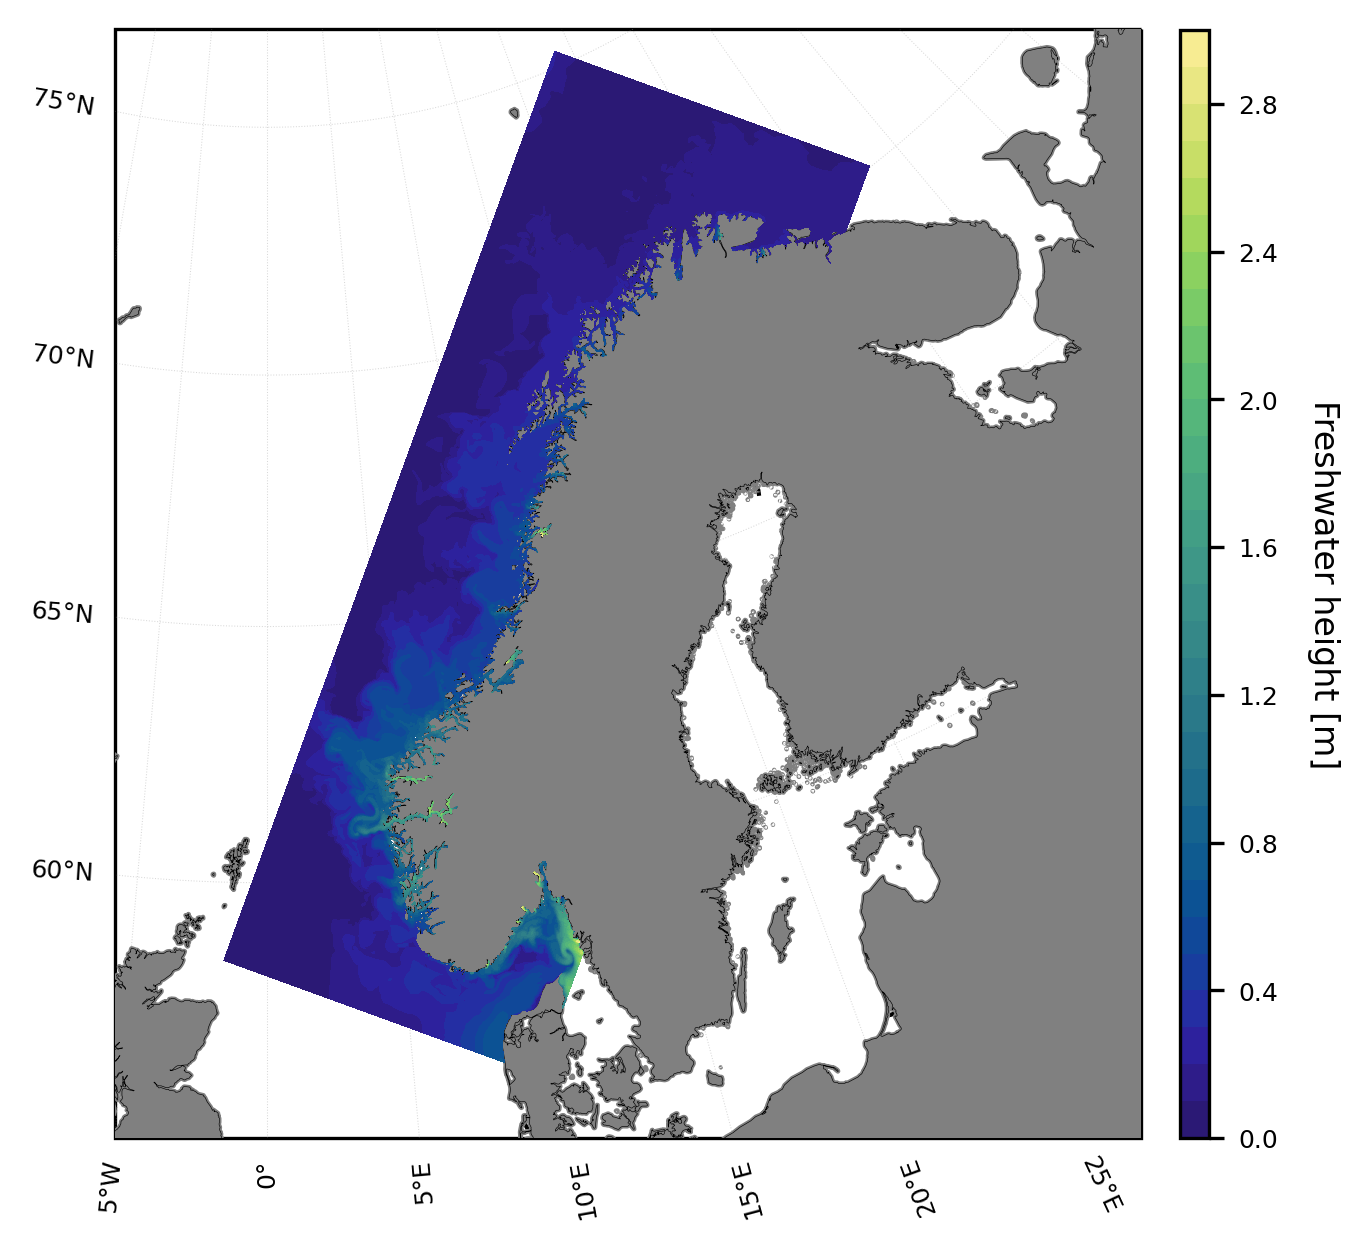

In [7]:
# Define projection
projection = ccrs.Stereographic(central_latitude=90, central_longitude=0, \
    false_easting=0, false_northing=0, true_scale_latitude=75, globe=None)

fig = plt.figure(dpi=300)
ax = plt.axes(projection=projection)

transform = ccrs.PlateCarree()._as_mpl_transform(ax)

F_plot = ax.contourf(lon, lat, fwh[0], levels=np.linspace(0,3,31), cmap=cmocean.cm.haline, transform=ccrs.PlateCarree(), zorder=2000)

### Add color, land etc ###
ax.add_feature(cfeature.LAKES, facecolor=("white"))
ax.add_feature(cfeature.OCEAN, facecolor=("#FFFFFF"))
ax.add_feature(cfeature.BORDERS)
ax.coastlines(resolution='10m', color='black', linewidth=.15, zorder=11)
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m', edgecolor='face', facecolor='gray'), zorder=10)

# Set extent
ax.set_extent([-5, 30, 55, 75], crs=ccrs.PlateCarree())

# Adjust grid labels
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='gray', linestyle='dotted', linewidth=0.25, draw_labels=True,\
     dms=True, x_inline=False, y_inline=False, alpha=0.3, zorder=20) # Display lat/lon grid

gl.top_labels = False
gl.bottom_labels =True
gl.left_labels = True
gl.right_labels = False

gl.ylocator = mticker.FixedLocator(np.arange(60, 95, 5))
gl.xlocator = mticker.FixedLocator(np.arange(-180, 180, 5))

gl.ylabel_style = {'color': 'k', 'weight': 'normal', 'size':6}
gl.xlabel_style = {'color': 'k', 'weight': 'normal', 'size':6, 'zorder':50}

# Define colorbar
cbar_ax = fig.add_axes([0.8, 0.11, 0.015, 0.7695]) # x, y, thickness, height
cbar = fig.colorbar(F_plot, cax=cbar_ax, orientation='vertical')

cbar.ax.xaxis.set_ticks_position("default")
cbar.ax.set_ylabel(r'Freshwater height [m]', fontsize=8, rotation=-90, labelpad=15)
cbar.ax.tick_params(labelsize=6)

##### And the PPE here:

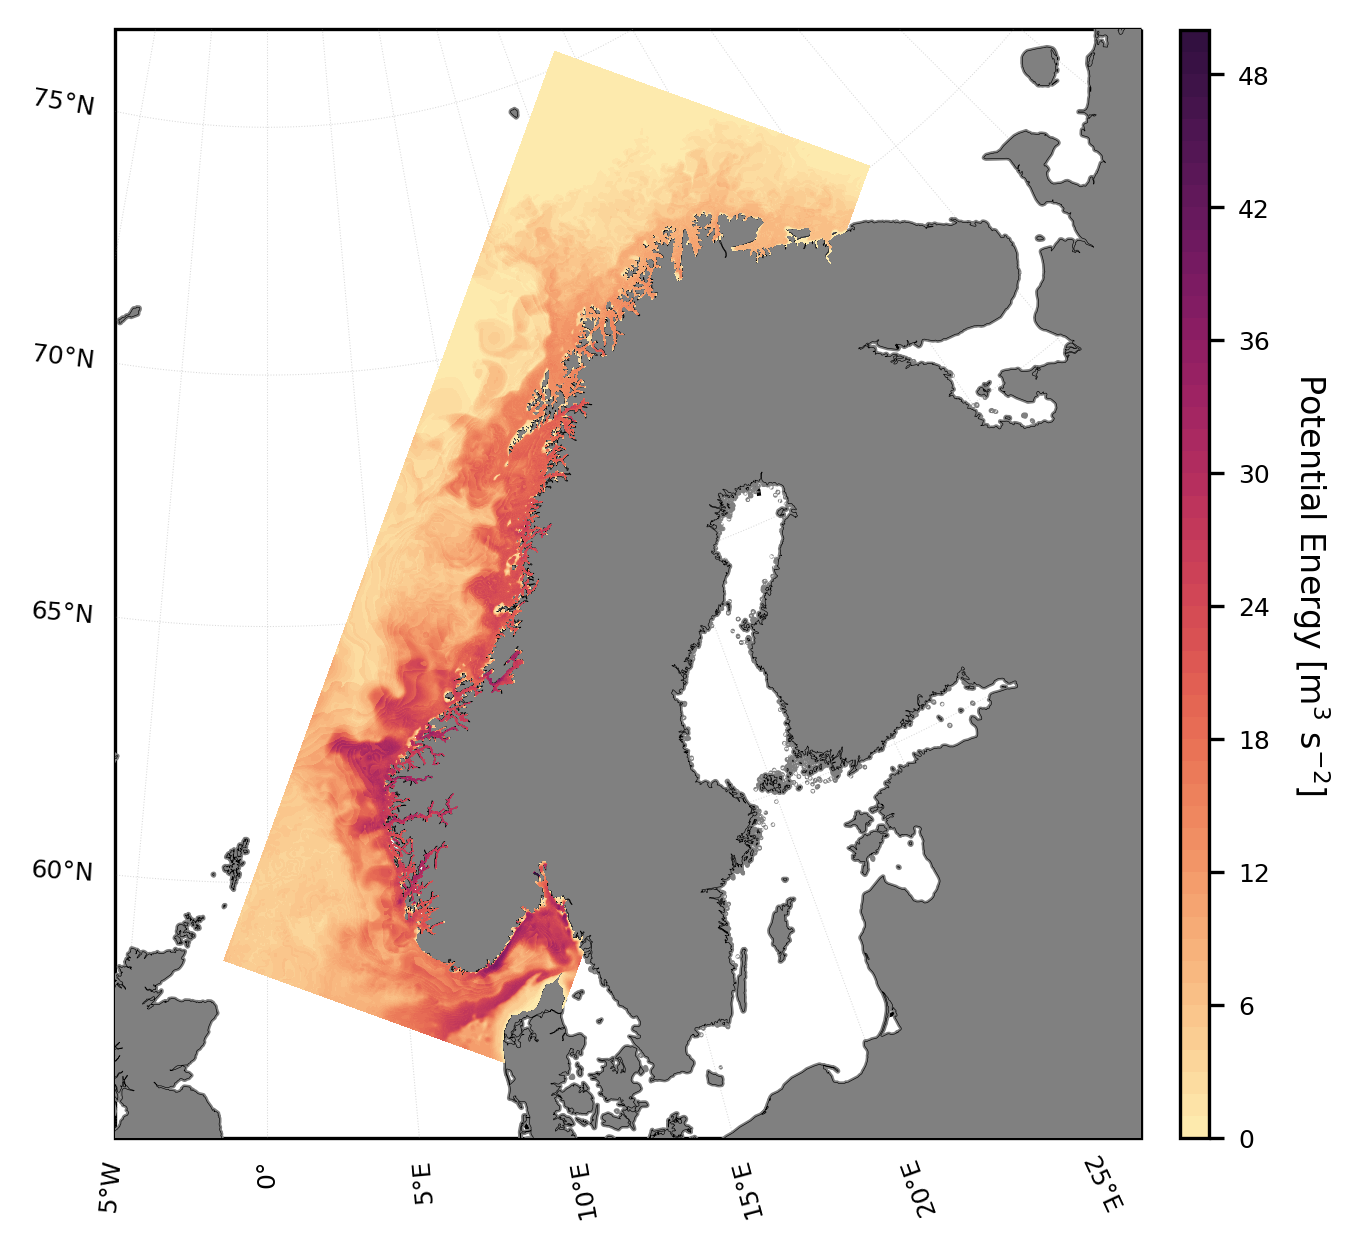

In [6]:
fig = plt.figure(dpi=300)
ax = plt.axes(projection=projection)

transform = ccrs.PlateCarree()._as_mpl_transform(ax)

P_plot = ax.contourf(lon, lat, ppe[0], levels=np.linspace(0,50,51), cmap=cmocean.cm.matter, transform=ccrs.PlateCarree(), zorder=2000)

### Add color, land etc ###
ax.add_feature(cfeature.LAKES, facecolor=("white"))
ax.add_feature(cfeature.OCEAN, facecolor=("#FFFFFF"))
ax.add_feature(cfeature.BORDERS)
ax.coastlines(resolution='10m', color='black', linewidth=.15, zorder=11)
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m', edgecolor='face', facecolor='gray'), zorder=10)

# Set extent
ax.set_extent([-5, 30, 55, 75], crs=ccrs.PlateCarree())

# Adjust grid labels
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='gray', linestyle='dotted', linewidth=0.25, draw_labels=True,\
     dms=True, x_inline=False, y_inline=False, alpha=0.3, zorder=20) # Display lat/lon grid

gl.top_labels = False
gl.bottom_labels =True
gl.left_labels = True
gl.right_labels = False

gl.ylocator = mticker.FixedLocator(np.arange(60, 95, 5))
gl.xlocator = mticker.FixedLocator(np.arange(-180, 180, 5))

gl.ylabel_style = {'color': 'k', 'weight': 'normal', 'size':6}
gl.xlabel_style = {'color': 'k', 'weight': 'normal', 'size':6, 'zorder':50}

# Define colorbar
cbar_ax = fig.add_axes([0.8, 0.11, 0.015, 0.7695]) # x, y, thickness, height
cbar = fig.colorbar(P_plot, cax=cbar_ax, orientation='vertical')

cbar.ax.xaxis.set_ticks_position("default")
cbar.ax.set_ylabel(r'Potential Energy [m$^3$ s$^{-2}$]', fontsize=8, rotation=-90, labelpad=15)
cbar.ax.tick_params(labelsize=6)

#### For the Sulafjord sub-domain now (160 m x 160 m)

Model must be 0 (whole domain) or 70 (Sulafjorden)
Sulafjord domain requested


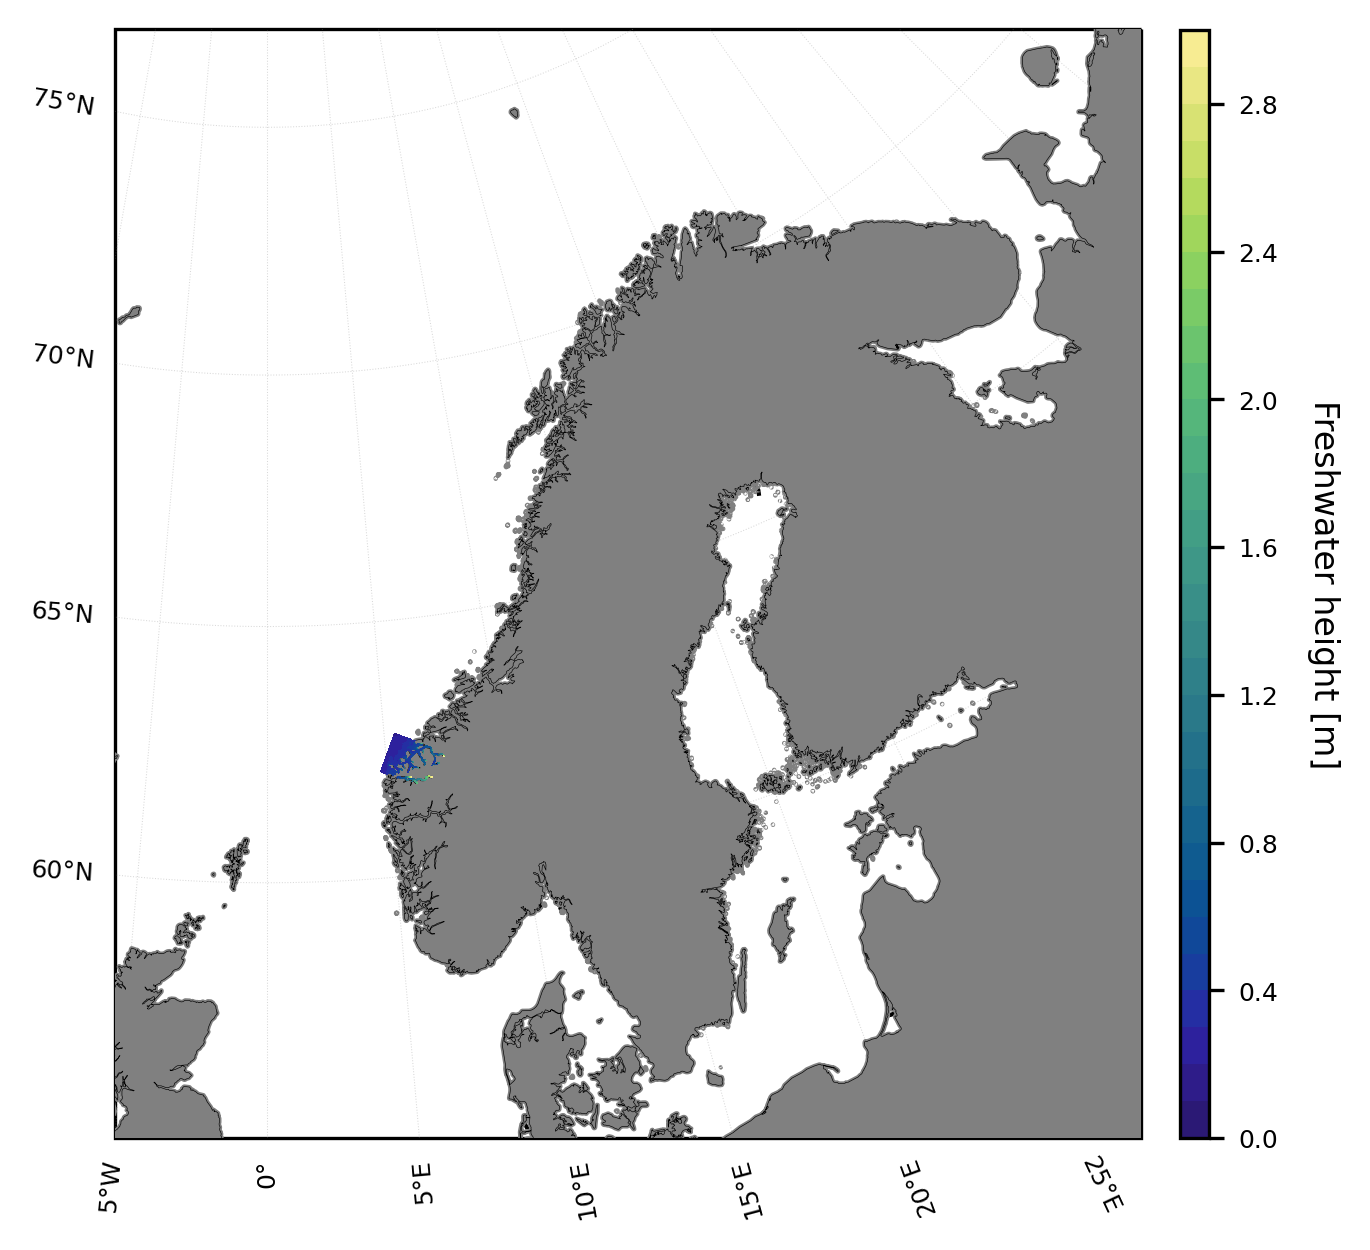

In [9]:
lon_sula, lat_sula, fwh_sula, ppe_sula = fwh_ppe(70, 4, 3, 2025)

# Define projection
projection = ccrs.Stereographic(central_latitude=90, central_longitude=0, \
    false_easting=0, false_northing=0, true_scale_latitude=75, globe=None)

fig = plt.figure(dpi=300)
ax = plt.axes(projection=projection)

transform = ccrs.PlateCarree()._as_mpl_transform(ax)

F_plot = ax.contourf(lon_sula, lat_sula, fwh_sula[0], levels=np.linspace(0,3,31), cmap=cmocean.cm.haline, transform=ccrs.PlateCarree(), zorder=2000)

### Add color, land etc ###
ax.add_feature(cfeature.LAKES, facecolor=("white"))
ax.add_feature(cfeature.OCEAN, facecolor=("#FFFFFF"))
ax.add_feature(cfeature.BORDERS)
ax.coastlines(resolution='10m', color='black', linewidth=.15, zorder=11)
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m', edgecolor='face', facecolor='gray'), zorder=10)

# Set extent
ax.set_extent([-5, 30, 55, 75], crs=ccrs.PlateCarree())

# Adjust grid labels
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='gray', linestyle='dotted', linewidth=0.25, draw_labels=True,\
     dms=True, x_inline=False, y_inline=False, alpha=0.3, zorder=20) # Display lat/lon grid

gl.top_labels = False
gl.bottom_labels =True
gl.left_labels = True
gl.right_labels = False

gl.ylocator = mticker.FixedLocator(np.arange(60, 95, 5))
gl.xlocator = mticker.FixedLocator(np.arange(-180, 180, 5))

gl.ylabel_style = {'color': 'k', 'weight': 'normal', 'size':6}
gl.xlabel_style = {'color': 'k', 'weight': 'normal', 'size':6, 'zorder':50}

# Define colorbar
cbar_ax = fig.add_axes([0.8, 0.11, 0.015, 0.7695]) # x, y, thickness, height
cbar = fig.colorbar(F_plot, cax=cbar_ax, orientation='vertical')

cbar.ax.xaxis.set_ticks_position("default")
cbar.ax.set_ylabel(r'Freshwater height [m]', fontsize=8, rotation=-90, labelpad=15)
cbar.ax.tick_params(labelsize=6)